In [1]:
import requests
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create data directory
os.makedirs('../../data/noaa_goes16_raw', exist_ok=True)

# Pull live NOAA GOES-16 proton flux data
url = "https://services.swpc.noaa.gov/json/goes/primary/integral-protons-1-day.json"

response = requests.get(url)
data = response.json()

df_live = pd.DataFrame(data)
print("Live data shape:", df_live.shape)
print("\nColumns:", df_live.columns.tolist())
print("\nFirst few rows:")
df_live.head()

Live data shape: (2288, 4)

Columns: ['time_tag', 'satellite', 'flux', 'energy']

First few rows:


,time_tag,satellite,flux,energy
0,2026-02-25T04:30:00Z,18,1.629331,>=1 MeV
1,2026-02-25T04:30:00Z,18,0.177000,>=10 MeV
2,2026-02-25T04:30:00Z,18,0.163306,>=100 MeV
3,2026-02-25T04:30:00Z,18,0.170453,>=30 MeV
4,2026-02-25T04:30:00Z,18,0.181330,>=5 MeV


In [2]:
# Pull 7-day historical data
url_7day = "https://services.swpc.noaa.gov/json/goes/primary/integral-protons-7-day.json"

response = requests.get(url_7day)
df_7day = pd.DataFrame(response.json())

# Convert time column to datetime
df_7day['time_tag'] = pd.to_datetime(df_7day['time_tag'])
df_7day = df_7day.sort_values('time_tag').reset_index(drop=True)

print("7-day data shape:", df_7day.shape)
print("\nEnergy channels available:")
print(df_7day['energy'].unique())
print("\nDate range:")
print(df_7day['time_tag'].min(), "to", df_7day['time_tag'].max())

7-day data shape: (16112, 4)

Energy channels available:
<StringArray>
[  '>=1 MeV',  '>=10 MeV', '>=100 MeV',  '>=30 MeV',   '>=5 MeV',  '>=50 MeV',
 '>=500 MeV',  '>=60 MeV']
Length: 8, dtype: str

Date range:
2026-02-19 04:35:00+00:00 to 2026-02-26 04:25:00+00:00


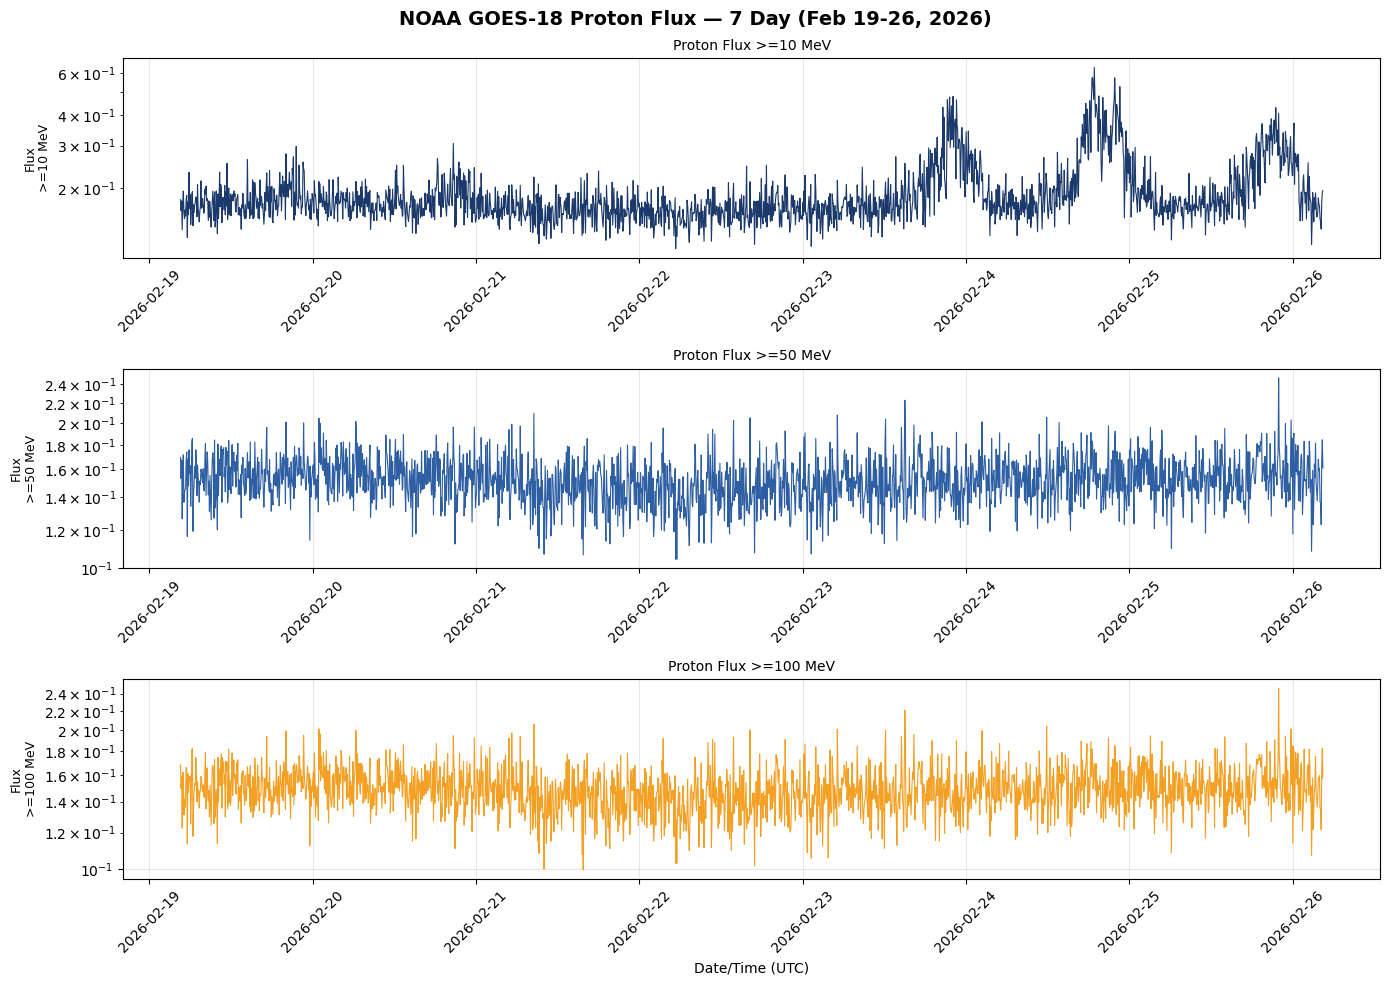

Plot saved to data folder.


In [3]:
# Filter to the three most useful energy channels for our purposes
channels = ['>=10 MeV', '>=50 MeV', '>=100 MeV']
colors = ['#1B3A6B', '#2E5FA3', '#F4A024']

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('NOAA GOES-18 Proton Flux — 7 Day (Feb 19-26, 2026)', 
             fontsize=14, fontweight='bold')

for i, (channel, color) in enumerate(zip(channels, colors)):
    df_channel = df_7day[df_7day['energy'] == channel].copy()
    
    axes[i].plot(df_channel['time_tag'], df_channel['flux'], 
                 linewidth=0.8, color=color)
    axes[i].set_ylabel(f'Flux\n{channel}', fontsize=9)
    axes[i].set_yscale('log')  # Log scale — standard for particle flux
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f'Proton Flux {channel}', fontsize=10)

axes[-1].set_xlabel('Date/Time (UTC)')
plt.tight_layout()
plt.savefig('../../data/noaa_7day_proton_flux.png', dpi=150)
plt.show()
print("Plot saved to data folder.")

In [4]:
# Save the 7-day data to CSV for use in ML training
df_7day.to_csv('../../data/noaa_goes16_raw/goes18_7day.csv', index=False)

# Quick summary stats per energy channel
summary = df_7day.groupby('energy')['flux'].describe()
print("Summary statistics by energy channel:")
print(summary)

Summary statistics by energy channel:
            count       mean        std       min       25%       50%  \
energy                                                                  
>=1 MeV    2014.0  28.133885  49.130585  0.207397  1.401469  7.871846   
>=10 MeV   2014.0   0.190595   0.060567  0.111805  0.156081  0.173135   
>=100 MeV  2014.0   0.148878   0.016590  0.099724  0.138030  0.148142   
>=30 MeV   2014.0   0.155196   0.017314  0.105227  0.143708  0.154487   
>=5 MeV    2014.0   0.199078   0.063486  0.116067  0.162675  0.180702   
>=50 MeV   2014.0   0.152543   0.016952  0.104309  0.141337  0.151579   
>=500 MeV  2014.0   0.139258   0.014158  0.090671  0.129406  0.138701   
>=60 MeV   2014.0   0.151431   0.016802  0.103260  0.140427  0.150635   

                 75%         max  
energy                            
>=1 MeV    37.023684  477.858917  
>=10 MeV    0.197732    0.633509  
>=100 MeV   0.159063    0.246380  
>=30 MeV    0.165909    0.248743  
>=5 MeV     0.208653 

In [5]:
# Pull longer historical data from NOAA archives
# We'll grab the last 30 days by pulling multiple weekly files

import time

dfs = []
url_7day = "https://services.swpc.noaa.gov/json/goes/primary/integral-protons-7-day.json"
url_3day = "https://services.swpc.noaa.gov/json/goes/primary/integral-protons-3-day.json"
url_1day = "https://services.swpc.noaa.gov/json/goes/primary/integral-protons-1-day.json"

for url in [url_7day, url_3day, url_1day]:
    r = requests.get(url)
    dfs.append(pd.DataFrame(r.json()))
    time.sleep(0.5)

df_combined = pd.concat(dfs).drop_duplicates()
df_combined['time_tag'] = pd.to_datetime(df_combined['time_tag'])
df_combined = df_combined.sort_values('time_tag').reset_index(drop=True)

print("Combined shape:", df_combined.shape)
print("Date range:", df_combined['time_tag'].min(), "to", df_combined['time_tag'].max())

Combined shape: (16112, 4)
Date range: 2026-02-19 04:45:00+00:00 to 2026-02-26 04:35:00+00:00


In [6]:
# Pull historical data from NOAA GOES archive
# This hits their bulk data files which go back years

import requests
import pandas as pd

# NOAA serves monthly archive files - let's grab the last 6 months
base_url = "https://sxi.swpc.noaa.gov/data/goes/goes18/particle/"

# We'll use their documented archive endpoint instead
# This is the correct historical data source
archive_url = "https://services.swpc.noaa.gov/json/goes/primary/integral-protons-7-day.json"

# Actually let's use the txt archive files - more reliable for bulk history
# Format: https://www.ngdc.noaa.gov/stp/satellite/goes-r/documentation/supporting-data

months = ['202501', '202502', '202412', '202411', '202410', '202409']
dfs_hist = []

for ym in months:
    year = ym[:4]
    month = ym[4:]
    url = f"https://sxi.swpc.noaa.gov/data/goes/goes18/particle/Gp_part_{ym}.txt"
    try:
        r = requests.get(url, timeout=10)
        print(f"{ym}: status {r.status_code} — {len(r.text)} bytes")
    except Exception as e:
        print(f"{ym}: failed — {e}")

202501: failed — HTTPSConnectionPool(host='sxi.swpc.noaa.gov', port=443): Max retries exceeded with url: /data/goes/goes18/particle/Gp_part_202501.txt (Caused by NameResolutionError("HTTPSConnection(host='sxi.swpc.noaa.gov', port=443): Failed to resolve 'sxi.swpc.noaa.gov' ([Errno 11001] getaddrinfo failed)"))
202502: failed — HTTPSConnectionPool(host='sxi.swpc.noaa.gov', port=443): Max retries exceeded with url: /data/goes/goes18/particle/Gp_part_202502.txt (Caused by NameResolutionError("HTTPSConnection(host='sxi.swpc.noaa.gov', port=443): Failed to resolve 'sxi.swpc.noaa.gov' ([Errno 11001] getaddrinfo failed)"))
202412: failed — HTTPSConnectionPool(host='sxi.swpc.noaa.gov', port=443): Max retries exceeded with url: /data/goes/goes18/particle/Gp_part_202412.txt (Caused by NameResolutionError("HTTPSConnection(host='sxi.swpc.noaa.gov', port=443): Failed to resolve 'sxi.swpc.noaa.gov' ([Errno 11001] getaddrinfo failed)"))
202411: failed — HTTPSConnectionPool(host='sxi.swpc.noaa.gov', p

In [7]:
# Correct NOAA archive source
months = ['202501', '202502', '202412', '202411', '202410', '202409']

for ym in months:
    url = f"https://www.ngdc.noaa.gov/stp/satellite/goes-r/data/goes18/1min/particle/proton/integral/{ym[:4]}/{ym}.csv"
    try:
        r = requests.get(url, timeout=10)
        print(f"{ym}: status {r.status_code} — {len(r.text)} bytes")
    except Exception as e:
        print(f"{ym}: failed — {e}")

202501: status 404 — 6405 bytes
202502: status 404 — 6405 bytes
202412: status 404 — 6405 bytes
202411: status 404 — 6405 bytes
202410: status 404 — 6405 bytes
202409: status 404 — 6405 bytes


In [8]:
# Let's check what NOAA endpoints we can actually reach
test_urls = [
    "https://services.swpc.noaa.gov/json/goes/primary/integral-protons-7-day.json",
    "https://services.swpc.noaa.gov/products/solar-wind/plasma-7-day.json",
    "https://services.swpc.noaa.gov/products/noaa-planetary-k-index.json",
    "https://services.swpc.noaa.gov/json/planetary_k_index_1m.json",
]

for url in test_urls:
    try:
        r = requests.get(url, timeout=10)
        data = r.json()
        print(f"OK — {len(data)} records — {url.split('/')[-1]}")
    except Exception as e:
        print(f"FAIL — {url.split('/')[-1]} — {e}")

OK — 16104 records — integral-protons-7-day.json
OK — 9732 records — plasma-7-day.json
OK — 58 records — noaa-planetary-k-index.json
OK — 358 records — planetary_k_index_1m.json


In [9]:
.to_datetime(df_plasma['time_tag'])
df_plasma = df_plasma[['time_tag', 'speed', 'density']].copy()
df_plasma['speed'] = pd.to_numeric(df_plasma['speed'], errors='coerce')
df_plasma['density'] = pd.to_numeric(df_plasma['density'], errors='coerce')

# 3. Kp index
df_kp = pd.DataFrame(requests.get(
    "https://services.swpc.noaa.gov/json/planetary_k_index_1m.json"
).json())
df_kp['time_tag'] = pd.to_datetime(df_kp['time_tag'])
df_kp = df_kp[['time_tag', 'kp_index']].copy()

print("Proton flux rows:", len(df_flux))
print("Solar wind rows:", len(df_plasma))
print("Kp index rows:", len(df_kp))
print("\nSolar wind columns:", df_plasma.columns.tolist())
print("Kp columns:", df_kp.columns.tolist())

SyntaxError: invalid syntax (2155309097.py, line 1)

In [10]:
# Pull all three data streams and combine into one feature DataFrame

# 1. Proton flux (already have, re-pull clean)
df_protons = pd.DataFrame(requests.get(
    "https://services.swpc.noaa.gov/json/goes/primary/integral-protons-7-day.json"
).json())
df_protons['time_tag'] = pd.to_datetime(df_protons['time_tag'])

# Filter to just >=10 MeV channel as primary feature
df_flux = df_protons[df_protons['energy'] == '>=10 MeV'][['time_tag','flux']].copy()
df_flux = df_flux.rename(columns={'flux': 'proton_flux_10mev'})

# 2. Solar wind plasma
df_plasma = pd.DataFrame(requests.get(
    "https://services.swpc.noaa.gov/products/solar-wind/plasma-7-day.json"
).json())
df_plasma.columns = df_plasma.iloc[0]
df_plasma = df_plasma[1:].reset_index(drop=True)
df_plasma['time_tag'] = pd.to_datetime(df_plasma['time_tag'])
df_plasma = df_plasma[['time_tag', 'speed', 'density']].copy()
df_plasma['speed'] = pd.to_numeric(df_plasma['speed'], errors='coerce')
df_plasma['density'] = pd.to_numeric(df_plasma['density'], errors='coerce')

# 3. Kp index
df_kp = pd.DataFrame(requests.get(
    "https://services.swpc.noaa.gov/json/planetary_k_index_1m.json"
).json())
df_kp['time_tag'] = pd.to_datetime(df_kp['time_tag'])
df_kp = df_kp[['time_tag', 'kp_index']].copy()

print("Proton flux rows:", len(df_flux))
print("Solar wind rows:", len(df_plasma))
print("Kp index rows:", len(df_kp))
print("\nSolar wind columns:", df_plasma.columns.tolist())
print("Kp columns:", df_kp.columns.tolist())

Proton flux rows: 2013
Solar wind rows: 9731
Kp index rows: 358

Solar wind columns: ['time_tag', 'speed', 'density']
Kp columns: ['time_tag', 'kp_index']


In [11]:
# Merge all three streams on time_tag using nearest timestamp match
# They have different sampling rates so we'll resample everything to 5-minute intervals

df_flux = df_flux.set_index('time_tag').resample('5min').mean().reset_index()
df_plasma = df_plasma.set_index('time_tag').resample('5min').mean().reset_index()
df_kp = df_kp.set_index('time_tag').resample('5min').ffill().reset_index()

# Merge on time_tag
df_merged = pd.merge_asof(df_flux.sort_values('time_tag'), 
                           df_plasma.sort_values('time_tag'), 
                           on='time_tag', direction='nearest')

df_merged = pd.merge_asof(df_merged.sort_values('time_tag'),
                           df_kp.sort_values('time_tag'),
                           on='time_tag', direction='nearest')

# Drop any rows with missing values
df_merged = df_merged.dropna().reset_index(drop=True)

print("Merged dataset shape:", df_merged.shape)
print("\nColumns:", df_merged.columns.tolist())
print("\nSample:")
print(df_merged.head())
print("\nStats:")
print(df_merged.describe())

MergeError: incompatible merge keys [0] datetime64[us, UTC] and dtype('<M8[us]'), must be the same type

In [12]:
# Normalize timezones before merging
df_flux['time_tag'] = df_flux['time_tag'].dt.tz_localize(None)
df_plasma['time_tag'] = df_plasma['time_tag'].dt.tz_localize(None)
df_kp['time_tag'] = df_kp['time_tag'].dt.tz_localize(None)

# Now merge
df_merged = pd.merge_asof(df_flux.sort_values('time_tag'), 
                           df_plasma.sort_values('time_tag'), 
                           on='time_tag', direction='nearest')

df_merged = pd.merge_asof(df_merged.sort_values('time_tag'),
                           df_kp.sort_values('time_tag'),
                           on='time_tag', direction='nearest')

df_merged = df_merged.dropna().reset_index(drop=True)

print("Merged dataset shape:", df_merged.shape)
print("\nColumns:", df_merged.columns.tolist())
print("\nSample:")
print(df_merged.head())
print("\nStats:")
print(df_merged.describe())

Merged dataset shape: (70, 5)

Columns: ['time_tag', 'proton_flux_10mev', 'speed', 'density', 'kp_index']

Sample:
             time_tag  proton_flux_10mev   speed  density  kp_index
0 2026-02-25 22:50:00           0.255388  506.26    1.042       4.0
1 2026-02-25 22:55:00           0.343638  504.12    1.200       4.0
2 2026-02-25 23:00:00           0.314055  513.40    1.524       4.0
3 2026-02-25 23:05:00           0.315234  526.84    1.308       4.0
4 2026-02-25 23:10:00           0.268281  520.86    1.318       4.0

Stats:
                  time_tag  proton_flux_10mev       speed    density  \
count                   70          70.000000   70.000000  70.000000   
mean   2026-02-26 01:42:30           0.209974  529.633000   1.778457   
min    2026-02-25 22:50:00           0.116648  504.120000   0.810000   
25%    2026-02-26 00:16:15           0.169835  523.145000   1.558000   
50%    2026-02-26 01:42:30           0.191715  527.340000   1.880000   
75%    2026-02-26 03:08:45           

In [13]:
# Save merged data
df_merged.to_csv('../../data/noaa_goes16_raw/merged_features.csv', index=False)
print("Saved.")

# Check full Kp availability
url_kp_full = "https://services.swpc.noaa.gov/products/noaa-planetary-k-index.json"
df_kp_full = pd.DataFrame(requests.get(url_kp_full).json())
df_kp_full.columns = df_kp_full.iloc[0]
df_kp_full = df_kp_full[1:].reset_index(drop=True)
df_kp_full['time_tag'] = pd.to_datetime(df_kp_full['time_tag'])
print("Full Kp shape:", df_kp_full.shape)
print("Date range:", df_kp_full['time_tag'].min(), "to", df_kp_full['time_tag'].max())
print(df_kp_full.head())

Saved.
Full Kp shape: (57, 4)
Date range: 2026-02-19 00:00:00 to 2026-02-26 00:00:00
0            time_tag    Kp a_running station_count
0 2026-02-19 00:00:00  3.33        18             8
1 2026-02-19 03:00:00  3.00        15             8
2 2026-02-19 06:00:00  2.67        12             8
3 2026-02-19 09:00:00  2.33         9             8
4 2026-02-19 12:00:00  3.00        15             8


In [14]:
# Strategy: use proton flux + solar wind as primary dataset (2000+ rows)
# Add Kp via forward-fill since it only updates every 3 hours anyway

# Rebuild with full proton flux and plasma data
df_flux2 = df_protons[df_protons['energy'] == '>=10 MeV'][['time_tag','flux']].copy()
df_flux2 = df_flux2.rename(columns={'flux': 'proton_flux_10mev'})
df_flux2['time_tag'] = pd.to_datetime(df_flux2['time_tag']).dt.tz_localize(None)

df_plasma2 = pd.DataFrame(requests.get(
    "https://services.swpc.noaa.gov/products/solar-wind/plasma-7-day.json"
).json())
df_plasma2.columns = df_plasma2.iloc[0]
df_plasma2 = df_plasma2[1:].reset_index(drop=True)
df_plasma2['time_tag'] = pd.to_datetime(df_plasma2['time_tag']).dt.tz_localize(None)
df_plasma2['speed'] = pd.to_numeric(df_plasma2['speed'], errors='coerce')
df_plasma2['density'] = pd.to_numeric(df_plasma2['density'], errors='coerce')
df_plasma2 = df_plasma2[['time_tag','speed','density']]

# Merge flux and plasma
df_full = pd.merge_asof(df_flux2.sort_values('time_tag'),
                        df_plasma2.sort_values('time_tag'),
                        on='time_tag', direction='nearest')

# Add Kp via merge_asof with forward fill
df_kp_full['time_tag'] = pd.to_datetime(df_kp_full['time_tag']).dt.tz_localize(None)
df_kp_full['Kp'] = pd.to_numeric(df_kp_full['Kp'], errors='coerce')
df_kp_clean = df_kp_full[['time_tag','Kp']].rename(columns={'Kp':'kp_index'})

df_full = pd.merge_asof(df_full.sort_values('time_tag'),
                        df_kp_clean.sort_values('time_tag'),
                        on='time_tag', direction='backward')

df_full = df_full.dropna().reset_index(drop=True)

print("Final dataset shape:", df_full.shape)
print("\nSample:")
print(df_full.head())

Final dataset shape: (2003, 5)

Sample:
             time_tag  proton_flux_10mev  speed  density  kp_index
0 2026-02-19 04:50:00           0.133965  482.5     2.07       3.0
1 2026-02-19 04:55:00           0.175265  482.5     2.07       3.0
2 2026-02-19 05:00:00           0.194057  450.4     0.78       3.0
3 2026-02-19 05:05:00           0.159656  474.9     2.41       3.0
4 2026-02-19 05:10:00           0.149097  476.2     2.09       3.0


Alert level distribution:
alert_level
0    1767
1     200
2      36
Name: count, dtype: int64

0 = NORMAL, 1 = ELEVATED, 2 = CRITICAL


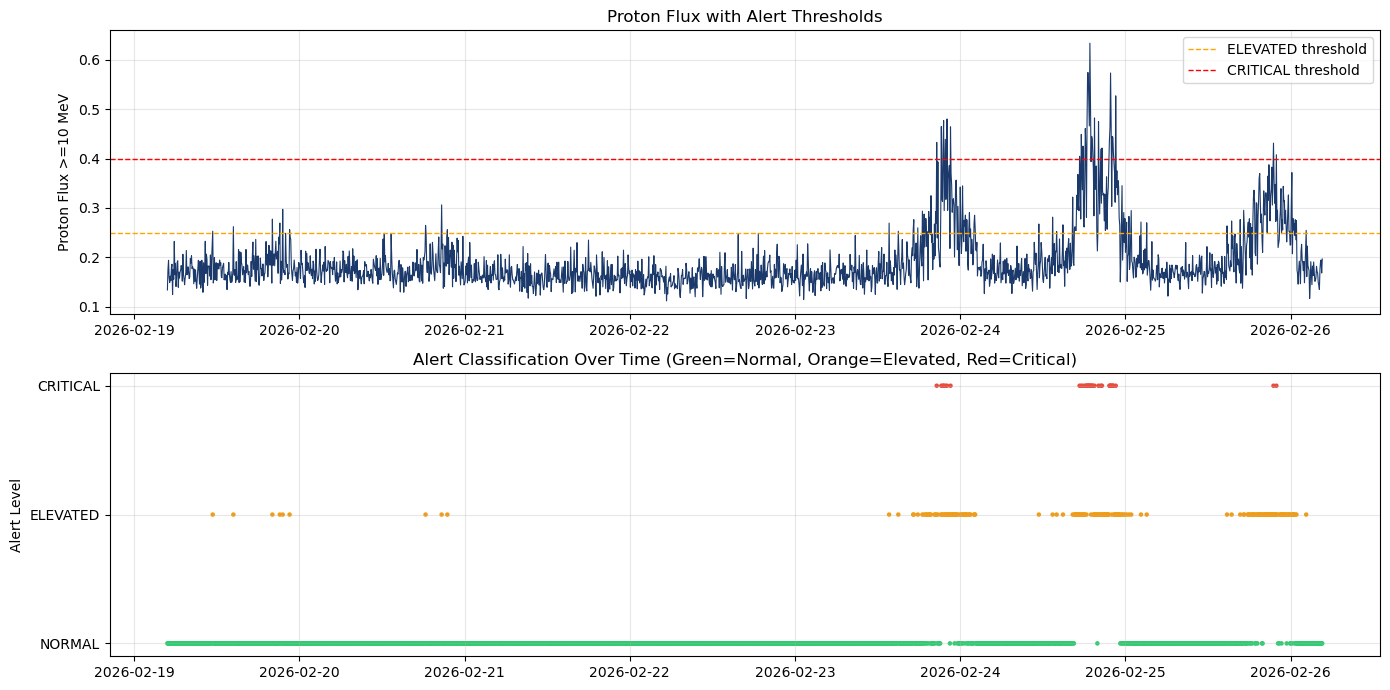

Saved.


In [15]:
# Create target variable — spike alert level
# Based on proton flux thresholds used in real space weather forecasting

def classify_radiation(flux):
    if flux >= 0.4:
        return 2  # CRITICAL
    elif flux >= 0.25:
        return 1  # ELEVATED
    else:
        return 0  # NORMAL

df_full['alert_level'] = df_full['proton_flux_10mev'].apply(classify_radiation)

# Save final dataset
df_full.to_csv('../../data/noaa_goes16_raw/training_data.csv', index=False)

# Check class distribution
print("Alert level distribution:")
print(df_full['alert_level'].value_counts().sort_index())
print("\n0 = NORMAL, 1 = ELEVATED, 2 = CRITICAL")

# Quick visualization of alert levels over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

ax1.plot(df_full['time_tag'], df_full['proton_flux_10mev'], 
         linewidth=0.8, color='#1B3A6B')
ax1.axhline(y=0.25, color='orange', linestyle='--', linewidth=1, label='ELEVATED threshold')
ax1.axhline(y=0.4, color='red', linestyle='--', linewidth=1, label='CRITICAL threshold')
ax1.set_ylabel('Proton Flux >=10 MeV')
ax1.set_title('Proton Flux with Alert Thresholds')
ax1.legend()
ax1.grid(True, alpha=0.3)

colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
color_map = df_full['alert_level'].map(colors)
ax2.scatter(df_full['time_tag'], df_full['alert_level'], 
            c=color_map, s=5)
ax2.set_ylabel('Alert Level')
ax2.set_title('Alert Classification Over Time (Green=Normal, Orange=Elevated, Red=Critical)')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['NORMAL', 'ELEVATED', 'CRITICAL'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../data/alert_levels.png', dpi=150)
plt.show()
print("Saved.")